In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')

In [22]:
import pandas as pd
import os

dataset_path = '/home/lakshya/jupyter/aml/class/archive(1)'
iimages = []
labels = []

# Loop over the subfolders in the dataset
for subfolder in os.listdir(dataset_path):
    subfolder_path = os.path.join(dataset_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue
    # Loop over the images in the subfolder
    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)
        iimages.append(image_path)
        labels.append(subfolder)
        
df = pd.DataFrame({'image': iimages, 'label': labels})

Note: you may need to restart the kernel to use updated packages.


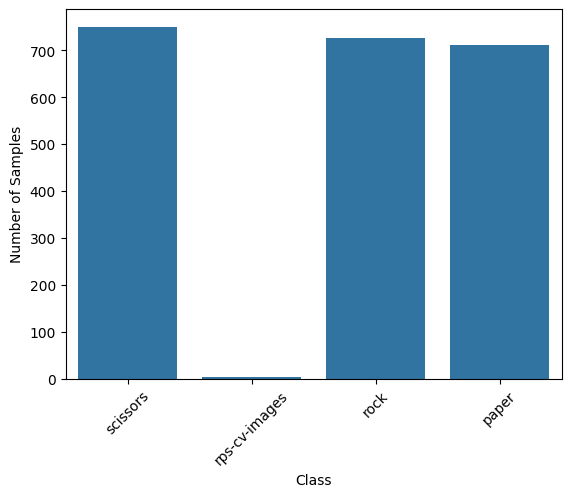

In [23]:
# Ensure seaborn is installed
%pip install seaborn

# Plot the classes
ax = sns.countplot(x=df.label)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

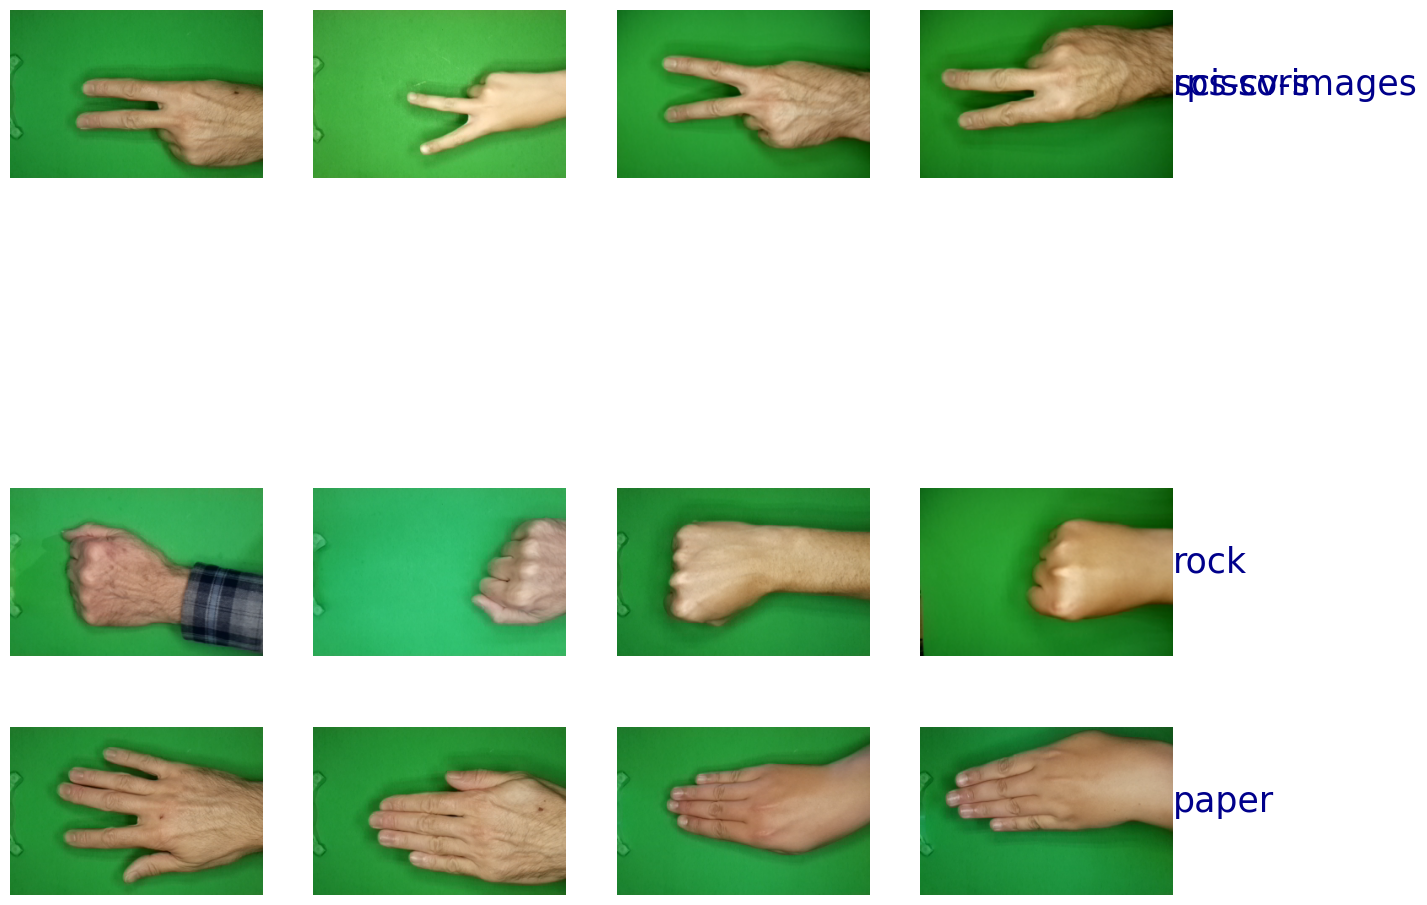

In [24]:
# Create figure and grid of subplots
fig = plt.figure(figsize=(15, 15))
gs = GridSpec(5, 4, figure=fig)

# Loop through each unique category in the DataFrame
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

for i, category in enumerate(df['label'].unique()):
    # Filter only image files (not directories and not text files)
    filepaths = [fp for fp in df[df['label'] == category]['image'].values
                 if os.path.isfile(fp) and fp.lower().endswith(image_extensions)]
    filepaths = filepaths[:4]  # Take up to 4 images
    for j, filepath in enumerate(filepaths):
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(plt.imread(filepath))
        ax.axis('off')
    ax.text(300, 100, category, fontsize=25, color='darkblue')
plt.show()

In [25]:
# Split dataset into train and val
X_train, X_val, y_train, y_val = train_test_split(df['image'], df['label'], test_size=0.4, random_state=42)
df_train = pd.DataFrame({'image': X_train, 'label': y_train})
df_val = pd.DataFrame({'image': X_val, 'label': y_val})

# Encode the labels
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.fit_transform(y_val)

In [26]:
# Create data augmentation options for image preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255)

# Create generator for train and val data
train = train_datagen.flow_from_dataframe(
    df_train,
    x_col='image',
    y_col='label',
    target_size=(50, 50),
    batch_size=64,
    class_mode='categorical',
    shuffle=True
)

val = val_datagen.flow_from_dataframe(
    df_val,
    x_col='image',
    y_col='label',
    target_size=(50, 50),
    batch_size=64,
    class_mode='categorical',
    shuffle=True
)

Found 1312 validated image filenames belonging to 3 classes.
Found 876 validated image filenames belonging to 3 classes.


In [27]:
# Create sequential model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(50, 50, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [28]:
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [30]:
# Save best model
callbacks = tf.keras.callbacks.ModelCheckpoint(filepath='best_model_keras.keras', 
                                               verbose=2, 
                                               save_best_only=True, 
                                               monitor='val_accuracy',
                                               mode='max')

# Train model
history = model.fit(train, epochs=20, validation_data=val, verbose=2, callbacks=[callbacks])

Epoch 1/20


2025-10-13 12:36:43.819802: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f0814005010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-13 12:36:43.819843: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-10-13 12:36:43.855707: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-13 12:36:44.091199: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-10-13 12:36:44.125276: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-13 12:36:44.


Epoch 1: val_accuracy improved from None to 0.53767, saving model to best_model_keras.keras
21/21 - 14s - 664ms/step - accuracy: 0.4428 - loss: 1.0545 - val_accuracy: 0.5377 - val_loss: 0.8504
Epoch 2/20

Epoch 2: val_accuracy improved from 0.53767 to 0.85616, saving model to best_model_keras.keras
21/21 - 3s - 150ms/step - accuracy: 0.6784 - loss: 0.7507 - val_accuracy: 0.8562 - val_loss: 0.4020
Epoch 3/20

Epoch 3: val_accuracy improved from 0.85616 to 0.91210, saving model to best_model_keras.keras
21/21 - 3s - 149ms/step - accuracy: 0.7767 - loss: 0.5423 - val_accuracy: 0.9121 - val_loss: 0.3134
Epoch 4/20

Epoch 4: val_accuracy did not improve from 0.91210
21/21 - 3s - 146ms/step - accuracy: 0.8163 - loss: 0.4667 - val_accuracy: 0.8071 - val_loss: 0.3803
Epoch 5/20

Epoch 5: val_accuracy did not improve from 0.91210
21/21 - 3s - 157ms/step - accuracy: 0.8537 - loss: 0.3790 - val_accuracy: 0.8676 - val_loss: 0.2852
Epoch 6/20

Epoch 6: val_accuracy improved from 0.91210 to 0.97717

In [ ]:
# Plot accuracy comparison
plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'],color="#E74C3C",marker='o')
plt.plot(history.history['val_accuracy'],color="#641E15",marker='h')
plt.title('Accuracy Comparison between Train and Validation Dataset',fontsize=15)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='best')
plt.show

NameError: name 'history' is not defined

<Figure size 1000x600 with 0 Axes>

<function matplotlib.pyplot.show(close=None, block=None)>

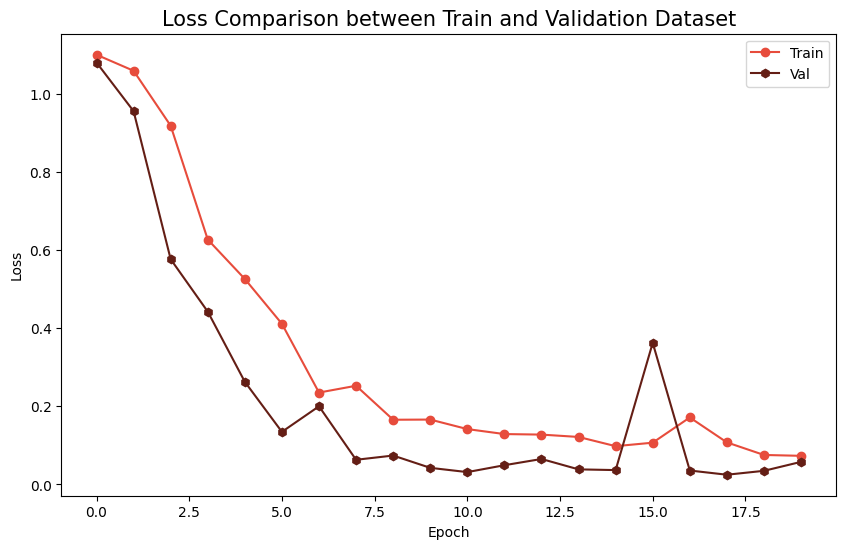

In [ ]:
# Plot loss comparison
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'],color="#E74C3C",marker='o')
plt.plot(history.history['val_loss'],color="#641E15",marker='h')
plt.title('Loss Comparison between Train and Validation Dataset',fontsize=15)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='best')
plt.show

In [ ]:
model.save('CNN_model.keras')
print("Model saved succesfully!")

Model saved succesfully!
